In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%run ../common.py

In [ ]:
def oneplot(df, y, yname, ax, xlabel=False):
    sns.swarmplot(data=df, x='nvaes', y=y, ax=ax)
    sns.boxplot(data=df, x='nvaes', y=y, boxprops={'facecolor':'None'}, showfliers=False, whiskerprops={'linewidth':1}, zorder=100, ax=ax)
    if xlabel:
        ax.set_xlabel('Number of cVAEs aggregated')
    else:
        ax.set_xlabel('')
    ax.set_ylim(0, None)
    ax.set_ylabel(yname)
    ax.spines[['top','right']].set_visible(False)

def plot(results, sigmncoef, phenoname):
    results['nsig'] = [ (sigmncoef != 0).sum() for sigmncoef in sigmncoefs ]
    results['logp'] = -np.log10(results['p'])
    corrs = pd.DataFrame(columns=['nvaes', 'corr'])
    for start, nvaes in [(0,1), (10,5), (20,10), (30,20)]:
        mysignmncoefs = sigmncoefs[start:start+10]
        for i in range(len(mysignmncoefs)):
            for j in range(i+1, len(mysignmncoefs)):
                c = np.corrcoef(mysignmncoefs[i], mysignmncoefs[j])[0,1]
                corrs = pd.concat([
                    corrs,
                    pd.DataFrame({'nvaes': nvaes, 'corr': c}, index=[0])
                ], ignore_index=True)

    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,5))
    oneplot(results, 'logp', '$-\\log_{10}(P)$', axs[0])
    oneplot(results, 'nsig', '# significant microniches (FDR 10%)', axs[1], xlabel=True)
    oneplot(corrs, 'corr', 'Corr. between sig. microniche coeffs.', axs[2])
    fig.suptitle(phenoname)

def read(pheno):
    results = pd.read_csv(f'_results/association-{pheno}.csv')
    sigmncoefs = np.load(f'_results/sigmncoefs-{pheno}.npy')
    return results, sigmncoefs

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_42089/105044867.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 8.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/yakir/m

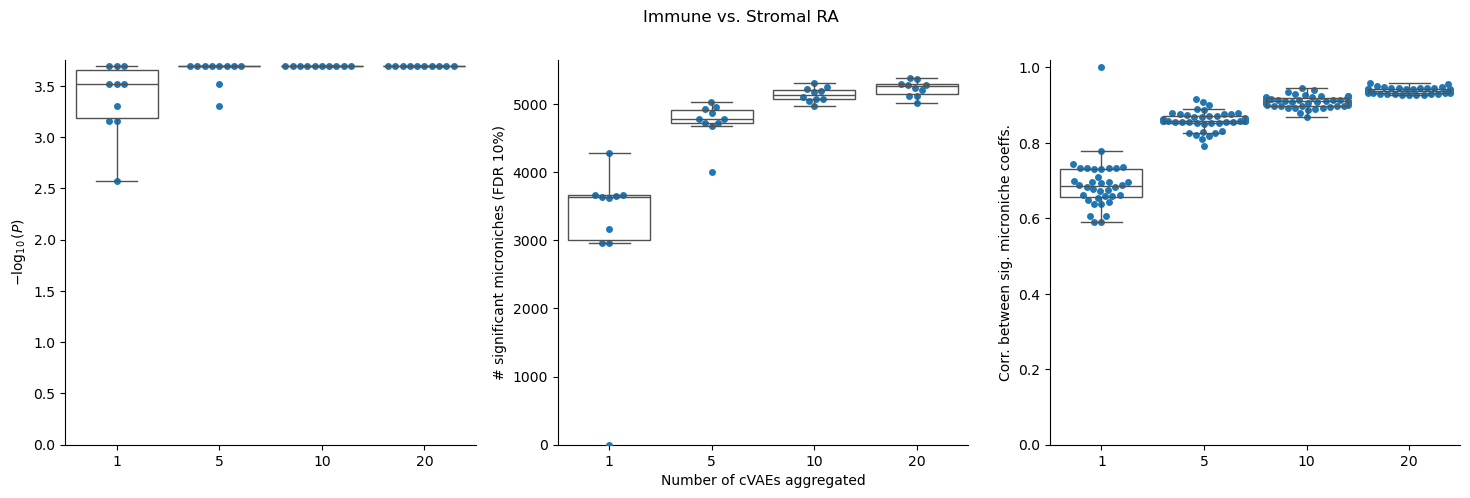

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_42089/105044867.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 15.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 24.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.9% 

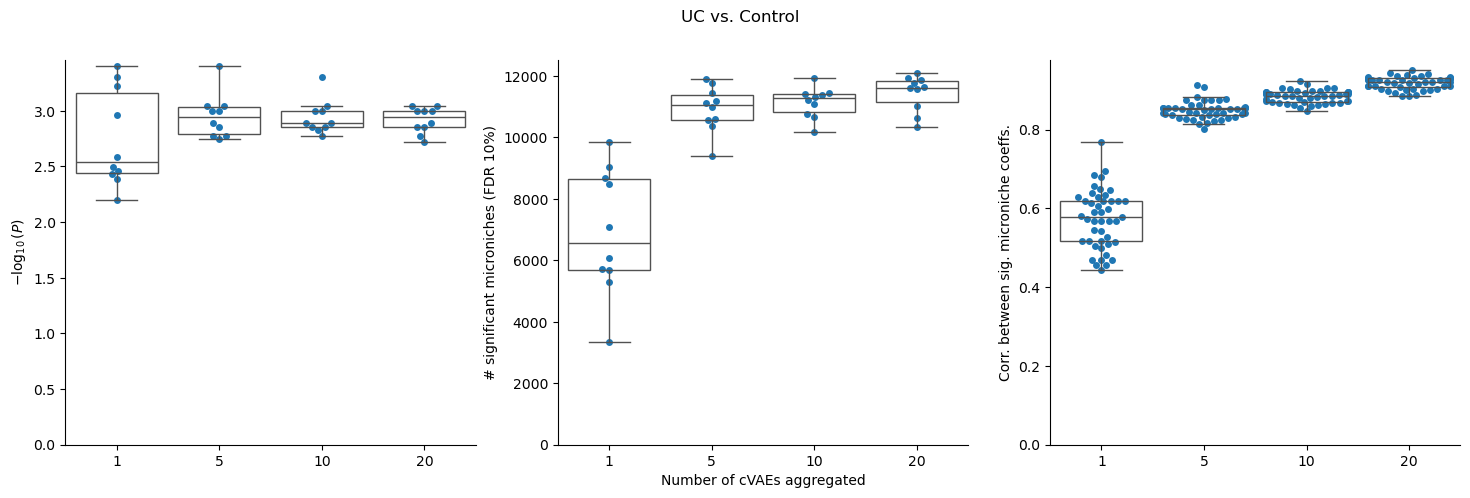

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_42089/105044867.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrs = pd.concat([
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 11.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/yakir/

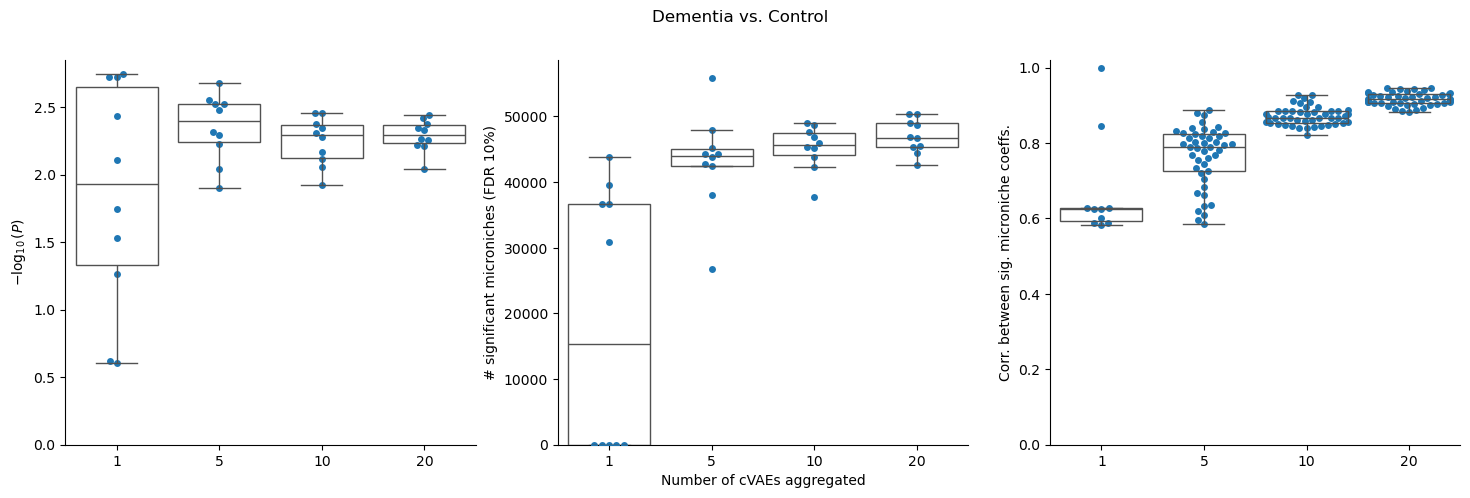

In [82]:
results, sigmncoefs = read('ra')
plot(results, sigmncoefs, 'Immune vs. Stromal RA')
plt.savefig('../_supp/fig.nvaes.ra.pdf', bbox_inches='tight', dpi=500)
plt.show()

results, sigmncoefs = read('uc')
plot(results, sigmncoefs, 'UC vs. Control')
plt.savefig('../_supp/fig.nvaes.uc.pdf', bbox_inches='tight', dpi=500)
plt.show()

results, sigmncoefs = read('alz')
plot(results, sigmncoefs, 'Dementia vs. Control')
plt.savefig('../_supp/fig.nvaes.alz.pdf', bbox_inches='tight', dpi=500)
plt.show()